# Fermi Blazar Spectral Analysis with blazarkit and the SDSS-V DR20 VAC 0034

## Learning Goals

By the end of this tutorial, you will:

- Understand how to access the Fermi/SDSS-V Blazar Value-Added Catalogue (SDSS-V VAC 0034)
  and explore its columns to characterise the blazar sample
- Know how to apply the `Z_FLAG` quality column to select sources with reliable
  spectroscopic redshifts and blazar classifications
- Be able to make population-level diagnostic plots — redshift distributions,
  jet fraction, and power-law slope — directly from the tabulated VAC parameters
- Understand how to use `SDSS_ID` and `MJD` from the VAC to load pre-computed spectral
  fitting results with blazarkit and visualise the full spectral decomposition. 
- Know how to use blazarkit to measure equivalent widths, inspect redshift posteriors, and
  compare multiple sources.  

## Introduction

Blazars are a special subclass of radio-loud Active Galactic Nuclei (AGN)
whose relativistic jets point almost directly toward Earth. The SDSS-V automated
spectroscopic pipeline systematically misclassifies these sources — assigning STAR,
GALAXY, or QSO classes — because it has no model for the non-thermal jet continuum.

This tutorial accompanies the Fermi/SDSS-V Blazar VAC 0034 presented in Nlowie et al. (submitted), 
which provides spectroscopic redshifts, blazar subclass classifications, and optical
jet fractions for 707 Fermi-LAT blazarcandidates observed in SDSS-V DR20. The pipeline fits 
each BOSS spectrum with sixphysically motivated spectral model families — combining a flexible 
power-law jetcontinuum with galaxy, QSO, and emission-line templates — and selects the best
model using the corrected Akaike Information Criterion (AICc).

SDSS-V VAC 0034 is described at: https://sas.sdss.org/dsi/file/select-fermi_blazar_redshifts/vac-34/env-BHM_BLAZAR 
SDSS-V VAC 0034 can be downloaded at: https://data.sdss5.org/sas/dr20/vac/bhm/blazar/boss_fermi_redshifts/


The companion Python package **blazarkit** provides tools for loading the pre-computed
spectral fitting results and visualising the full decomposition for any source in the
sample. This tutorial demonstrates the full workflow — from loading the VAC and
exploring sample properties, to detailed spectral inspection of individual sources.

## Imports

This tutorial requires the following Python packages:

- `numpy` — array operations
- `matplotlib` — plotting
- `astropy` — reading FITS files and tables
- `blazarkit` — spectral visualisation and analysis
- `sdss_access` — accessing VAC files from the SDSS SAS (optional until DR20 is public)

Missing packages can be installed via:
```bash
pip install numpy matplotlib astropy sdss-access
pip install git+https://github.com/minlowie/Blazar-Analysis-Pipeline.git
```

> **Note:** If you already have `sdss_access` installed but encounter issues,
> try upgrading: `pip install --upgrade sdss-access sdss-tree`


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from collections import Counter
%matplotlib inline

---
# Part 1: Exploring the VAC

The Value-Added Catalogue (VAC) contains one row per source with tabulated
parameters from the multi-component spectral fitting pipeline. It is the starting point for
any analysis — use it to understand the sample, filter by quality, and identify
sources of interest before loading them into blazarkit.

The key column linking the VAC to blazarkit is `SDSS_ID`.

## 1. Load the VAC

The VAC is available through the SDSS SAS via `sdss_access` upon publication
of SDSS-V DR20. The commented code below shows how to access it programmatically
once DR20 is public. Until then load a local copy.

The key columns for linking to blazarkit are `SDSS_ID` and `Z_FLAG`.

In [6]:
# Option 1 — via sdss_access
import sdss_access
import sdss_access.path
sdss_path = sdss_access.path.Path(release='dr20', verbose=True)
access    = sdss_access.Access(release='dr20', verbose=True)
vac_file  = sdss_path.full('fermi_blazar_redshifts', v_vac='1.0.0')
if not sdss_path.exists('', full=vac_file):
    access.remote()
    access.add('fermi_blazar_redshifts', v_vac='1.0.0')
    access.set_stream()
    access.commit()
vac = Table.read(vac_file)
print(f'Columns: {vac.colnames}')

# # Option 2 — load a local copy
# vac = Table(fits.open('fermi_blazar_vac_dr20.fits')[1].data)
# print(f'VAC loaded: {len(vac)} sources')
# print(f'Columns: {vac.colnames}')

Columns: ['SDSS_ID', 'MJD', 'SDSS_NAME', 'FGL_NAME', 'FGL_CLASS', 'BEST_MODEL', 'SDSS_CLASS', 'Z_SDSS', 'Z_fit', 'Z_fit_err', 'rchi2_fit', 'rchi2_sdss', 'Jet_Fraction', 'PL_alpha', 'PL_delta', 'SNR', 'Z_FLAG']


## 2. Sample breakdown and quality flags

We start by understanding the sample composition and identifying which sources
have reliable redshifts and classifications.

The `Z_FLAG` column is the most important quality indicator:

| Z_FLAG | Meaning |
|--------|---------|
| `0` | Reliable redshift and classification |
| `1` | Unreliable — featureless power-law, no spectral anchor (7 sources) |
| `2` | Low-confidence redshift — PL+Galaxy at z > 1.8 |
| `3` | Low spectral quality — SNR < 3 |

**Always filter on `Z_FLAG == 0` for population-level analyses.**

In [7]:
# Best-fit model breakdown
print(f"{'Model':<25} {'N':>5}  {'%':>6}")
print('-' * 40)
for model, n in sorted(Counter(vac['BEST_MODEL']).items(), key=lambda x: -x[1]):
    print(f"  {model:<23} {n:>5}  {100*n/len(vac):>5.1f}%")

# Fermi classification breakdown. This is the blazar classifications used in the 4FGL catalogue. 
print(f"\n{'FGL Class':<15} {'N':>5}  {'%':>6}")
print('-' * 30)
for cls, n in sorted(Counter(vac['FGL_CLASS']).items(), key=lambda x: -x[1]):
    print(f"  {cls:<13} {n:>5}  {100*n/len(vac):>5.1f}%")

# Z_FLAG breakdown
print(f"\n{'Z_FLAG':<8} {'N':>5}  Description")
print('-' * 55)
flag_desc = {
    0: 'Reliable',
    1: 'Unreliable — featureless PL, no redshift anchor',
    2: 'Low-confidence redshift (PL+Galaxy z > 1.8)',
    3: 'Low spectral quality (SNR < 3)',
}
for flag, desc in flag_desc.items():
    n = int(np.sum(np.array(vac['Z_FLAG'], dtype=int) == flag))
    print(f"  {flag:<6} {n:>5}  {desc}")

# Reliable sample for all further analysis
vac_reliable = vac[np.array(vac['Z_FLAG'], dtype=int) == 0]
print(f"\nReliable sources (Z_FLAG=0): {len(vac_reliable)} / {len(vac)}")

Model                         N       %
----------------------------------------
  Powerlaw+Galaxy           420   59.4%
  Powerlaw+Lines (High EW Line)    75   10.6%
  Powerlaw+Lines (Median Line)    58    8.2%
  Powerlaw+Lines (High Blueshift Line)    27    3.8%
  Powerlaw+QSO (Red z=0.5 (ebv = 0.2))    25    3.5%
  Powerlaw+QSO (High Blueshift z=0.2)    18    2.5%
  Powerlaw+QSO (High EW z=0.2)    18    2.5%
  Powerlaw+QSO (High EW z=1.5)    16    2.3%
  Powerlaw+QSO (High Blueshift z=1.5)    10    1.4%
  Powerlaw+QSO (Red z =0.5 (ebv = 0.1))     7    1.0%
  Powerlaw+QSO (Default z=0.2)     7    1.0%
  Galaxy                      5    0.7%
  Powerlaw+QSO (Default z=1.5)     5    0.7%
  Powerlaw                    5    0.7%
  QSO (Red z=0.5 (ebv = 0.2))     2    0.3%
  QSO (Default z=0.2)         2    0.3%
  QSO (High Blueshift z=1.5)     2    0.3%
  QSO (High EW z=1.5)         2    0.3%
  QSO (Red z =0.5 (ebv = 0.1))     2    0.3%
  QSO (Default z=1.5)         1    0.1%

FGL Class  

## 3. Population plots from the VAC

The VAC columns alone are sufficient for population-level analysis.
Here we plot redshift and jet fraction distributions, and the power-law slope
distribution — all from the tabulated parameters, using only `Z_FLAG == 0` sources.

We separate BL Lac candidates (PL+Galaxy or Powerlaw) from FSRQ candidates
(PL+QSO or PL+Lines) and apply S/N >= 3.

In [8]:
# Work from reliable sources only
bl_mask   = np.array(['Powerlaw+Galaxy' in str(m) or str(m) == 'Powerlaw'
                       for m in vac_reliable['BEST_MODEL']])
fsrq_mask = np.array(['Powerlaw+QSO' in str(m) or 'Powerlaw+Lines' in str(m)
                       for m in vac_reliable['BEST_MODEL']])

z_vals    = np.array(vac_reliable['Z_fit'],        dtype=float)
jet_vals  = np.array(vac_reliable['Jet_Fraction'], dtype=float)
alpha_vals= np.array(vac_reliable['PL_alpha'],     dtype=float)
sn_vals   = np.array(vac_reliable['SNR'],          dtype=float)
sn_mask   = sn_vals >= 3

print(f'BL Lac candidates (Z_FLAG=0, S/N>=3): {np.sum(bl_mask & sn_mask)}')
print(f'FSRQ candidates   (Z_FLAG=0, S/N>=3): {np.sum(fsrq_mask & sn_mask)}')

BL Lac candidates (Z_FLAG=0, S/N>=3): 355
FSRQ candidates   (Z_FLAG=0, S/N>=3): 214


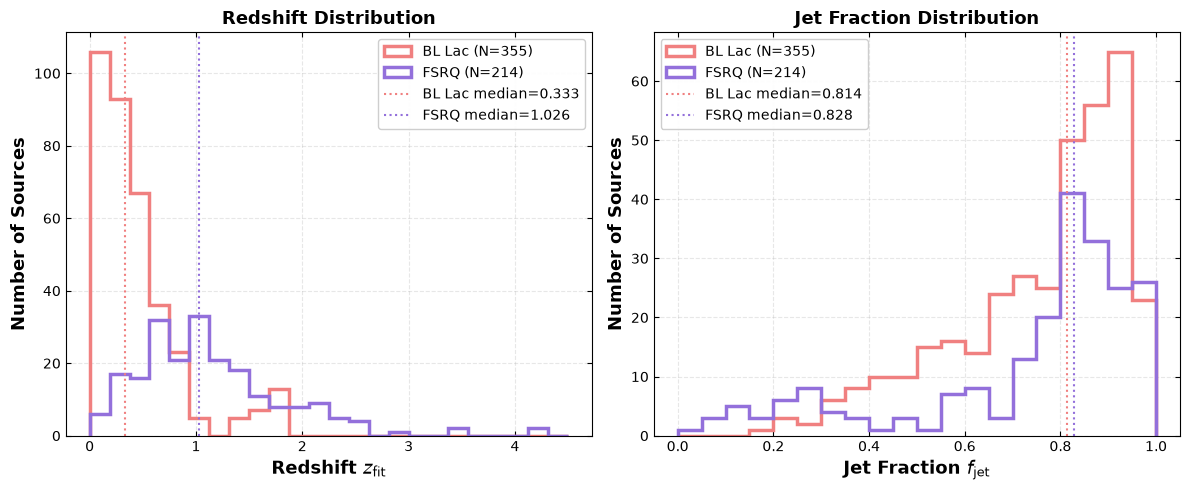

In [9]:
# Redshift and jet fraction distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bins_z   = np.linspace(0, 4.5, 25)
bins_jet = np.linspace(0, 1, 21)

for ax, vals, bins, xlabel, title in [
    (ax1, z_vals,   bins_z,   r'Redshift $z_{\rm fit}$',     'Redshift Distribution'),
    (ax2, jet_vals, bins_jet, r'Jet Fraction $f_{\rm jet}$', 'Jet Fraction Distribution'),
]:
    ax.hist(vals[bl_mask & sn_mask], bins=bins, histtype='step',
            color='lightcoral', lw=2.5,
            label=f'BL Lac (N={np.sum(bl_mask & sn_mask)})')
    ax.hist(vals[fsrq_mask & sn_mask], bins=bins, histtype='step',
            color='mediumpurple', lw=2.5,
            label=f'FSRQ (N={np.sum(fsrq_mask & sn_mask)})')
    ax.axvline(np.nanmedian(vals[bl_mask & sn_mask]),
               color='lightcoral', ls=':', lw=1.5,
               label=f'BL Lac median={np.nanmedian(vals[bl_mask & sn_mask]):.3f}')
    ax.axvline(np.nanmedian(vals[fsrq_mask & sn_mask]),
               color='mediumpurple', ls=':', lw=1.5,
               label=f'FSRQ median={np.nanmedian(vals[fsrq_mask & sn_mask]):.3f}')
    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Sources', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, framealpha=0.95)
    ax.grid(alpha=0.3, linestyle='--')
    ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

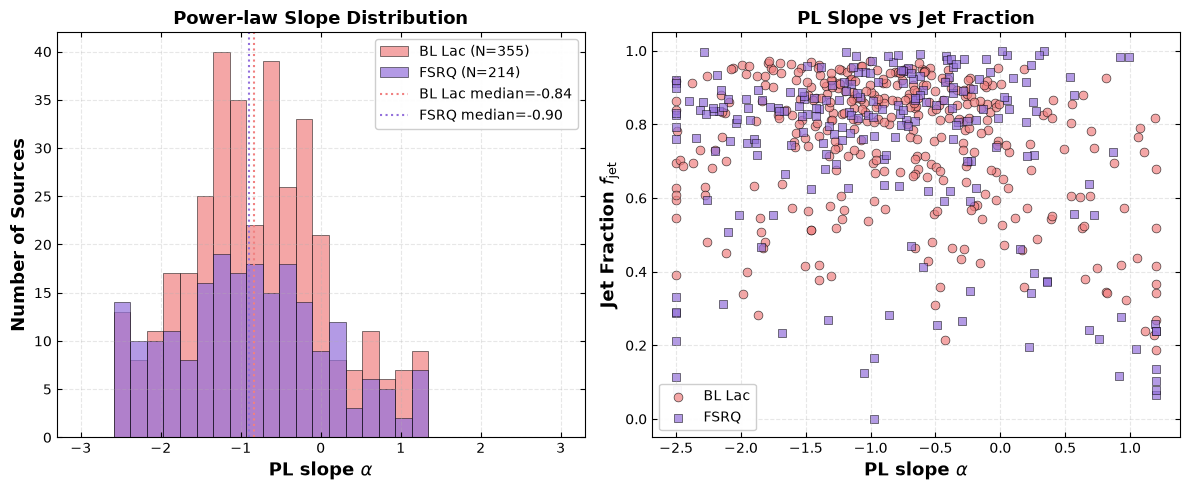

In [10]:
# Power-law slope distribution
finite_mask = np.isfinite(alpha_vals)
bins_alpha  = np.linspace(-3, 3, 30)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — step histogram
axes[0].hist(alpha_vals[bl_mask & sn_mask & finite_mask], bins=bins_alpha,
             color='lightcoral', alpha=0.7, edgecolor='black', linewidth=0.5,
             label=f'BL Lac (N={np.sum(bl_mask & sn_mask & finite_mask)})')
axes[0].hist(alpha_vals[fsrq_mask & sn_mask & finite_mask], bins=bins_alpha,
             color='mediumpurple', alpha=0.7, edgecolor='black', linewidth=0.5,
             label=f'FSRQ (N={np.sum(fsrq_mask & sn_mask & finite_mask)})')
axes[0].axvline(np.nanmedian(alpha_vals[bl_mask & sn_mask & finite_mask]),
                color='lightcoral', ls=':', lw=1.5,
                label=f'BL Lac median={np.nanmedian(alpha_vals[bl_mask & sn_mask & finite_mask]):.2f}')
axes[0].axvline(np.nanmedian(alpha_vals[fsrq_mask & sn_mask & finite_mask]),
                color='mediumpurple', ls=':', lw=1.5,
                label=f'FSRQ median={np.nanmedian(alpha_vals[fsrq_mask & sn_mask & finite_mask]):.2f}')
axes[0].set_xlabel(r'PL slope $\alpha$', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Sources', fontsize=13, fontweight='bold')
axes[0].set_title('Power-law Slope Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, framealpha=0.95)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].tick_params(direction='in', top=True, right=True)

# Right — alpha vs jet fraction
axes[1].scatter(alpha_vals[bl_mask & sn_mask & finite_mask],
                jet_vals[bl_mask & sn_mask & finite_mask],
                color='lightcoral', s=40, alpha=0.7, label='BL Lac',
                edgecolors='black', linewidths=0.5)
axes[1].scatter(alpha_vals[fsrq_mask & sn_mask & finite_mask],
                jet_vals[fsrq_mask & sn_mask & finite_mask],
                color='mediumpurple', s=40, alpha=0.7, label='FSRQ',
                edgecolors='black', linewidths=0.5, marker='s')
axes[1].set_xlabel(r'PL slope $\alpha$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'Jet Fraction $f_{\rm jet}$', fontsize=13, fontweight='bold')
axes[1].set_title('PL Slope vs Jet Fraction', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, framealpha=0.95)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()

## 4. Selecting sources of interest

Use the VAC columns to filter the sample to sources matching your scientific
criteria. The `SDSS_ID` column is what links the VAC to blazarkit.

In Part 2 we will take these `SDSS_ID` values and load their full spectral
fitting results for detailed inspection.

In [11]:
# Example 1 — Top BL Lac candidates by S/N
bl_vac = vac_reliable[np.array(['Powerlaw+Galaxy' in str(m) or str(m) == 'Powerlaw'
                                  for m in vac_reliable['BEST_MODEL']])]
bl_vac = bl_vac[np.array(bl_vac['SNR'], dtype=float) >= 3]
bl_vac.sort('SNR')
bl_vac.reverse()

print('Top 5 BL Lac candidates by S/N:')
for row in bl_vac[:5]:
    print(f"  SDSS_ID={row['SDSS_ID']}  z={row['Z_fit']:.3f}  "
          f"S/N={row['SNR']:.1f}  f_jet={row['Jet_Fraction']:.2f}  "
          f"Model={row['BEST_MODEL']}")

# Example 2 — Top PL+Lines (FSRQ) candidates by S/N
pllines_vac = vac_reliable[np.array(['Powerlaw+Lines' in str(m)
                                      for m in vac_reliable['BEST_MODEL']])]
pllines_vac.sort('SNR')
pllines_vac.reverse()

print('\nTop 5 PL+Lines (FSRQ) candidates by S/N:')
for row in pllines_vac[:5]:
    print(f"  SDSS_ID={row['SDSS_ID']}  z={row['Z_fit']:.3f}  "
          f"S/N={row['SNR']:.1f}  f_jet={row['Jet_Fraction']:.2f}")
    
# Example 3 - Top PL+QSO (FSRQ) candidates by S/N
plqso_vac = vac_reliable[np.array(['Powerlaw+QSO' in str(m)
                                     for m in vac_reliable['BEST_MODEL']])]
plqso_vac.sort('SNR')
plqso_vac.reverse()

print('\nTop 5 PL+QSO (FSRQ) candidates by S/N:')
for row in plqso_vac[:5]:
    print(f"  SDSS_ID={row['SDSS_ID']}  z={row['Z_fit']:.3f}  "
          f"S/N={row['SNR']:.1f}  f_jet={row['Jet_Fraction']:.2f}")

Top 5 BL Lac candidates by S/N:
  SDSS_ID=80861309  z=0.183  S/N=54.1  f_jet=0.87  Model=Powerlaw+Galaxy
  SDSS_ID=56366226  z=0.427  S/N=49.3  f_jet=0.95  Model=Powerlaw+Galaxy
  SDSS_ID=92558683  z=0.270  S/N=48.0  f_jet=0.85  Model=Powerlaw+Galaxy
  SDSS_ID=79079649  z=0.259  S/N=43.6  f_jet=0.92  Model=Powerlaw+Galaxy
  SDSS_ID=95998275  z=0.138  S/N=40.4  f_jet=0.67  Model=Powerlaw+Galaxy

Top 5 PL+Lines (FSRQ) candidates by S/N:
  SDSS_ID=61915043  z=1.064  S/N=40.0  f_jet=0.91
  SDSS_ID=79816708  z=0.893  S/N=31.2  f_jet=0.95
  SDSS_ID=69077809  z=0.461  S/N=30.8  f_jet=0.75
  SDSS_ID=60819167  z=0.716  S/N=29.7  f_jet=0.98
  SDSS_ID=64415441  z=1.966  S/N=29.3  f_jet=0.86

Top 5 PL+QSO (FSRQ) candidates by S/N:
  SDSS_ID=75253279  z=0.267  S/N=54.0  f_jet=0.95
  SDSS_ID=61543192  z=0.683  S/N=48.3  f_jet=0.81
  SDSS_ID=71082058  z=1.942  S/N=42.1  f_jet=0.47
  SDSS_ID=69198379  z=0.682  S/N=40.1  f_jet=0.91
  SDSS_ID=78650021  z=0.381  S/N=33.4  f_jet=0.21


---
# Part 2: Spectral Analysis with blazarkit

blazarkit loads the full pre-computed spectral fitting results for any source
and gives you access to the complete spectral decomposition — the observed
spectrum, all model fits, component contributions, redshift posteriors, and
equivalent width measurements.

We start by initialising the cache, then show how to go from VAC selection
directly to spectral inspection.

## 5. Initialise the cache

`NAKBlaZarCache` manages access to the pre-computed results. On first access
it streams each file automatically and saves it locally — no authentication
required. All subsequent calls load instantly from local storage.

Files stream in this priority order: local → Zenodo (after DR20) → Dropbox → Google Drive.

### 5.1 Import blazarkit

In [12]:
# Reload to ensure latest version
import importlib
import blazarkit
importlib.reload(blazarkit)

from blazarkit import (
    NAKBlaZarCache, bz_inspect, bz_classify, bz_lines,
    bz_population, measure_ew, normalize_shape,
    get_redshift_peaks, get_mjd,bz_compare
)

print('blazarkit reloaded successfully.')

blazarkit reloaded successfully.


### 5.2 Initialise NAKBlaZarCache

In [13]:
# Default — streams automatically, saves to blazar_cache/
cache = NAKBlaZarCache()

# Or point to an existing local folder:
# cache = NAKBlaZarCache(cache_dir='/path/to/your/cache')

cached_files = cache.list_cached_objects()
# Output: 'Found 0 cached objects' on first run — expected.
# Files appear here after loading sources for the first time.

Found 7 cached objects in blazar_cache/


## 6. From VAC to blazarkit — inspecting selected sources

This is the recommended workflow:
1. Use the VAC to select sources of interest (Part 1)
2. Extract their `SDSS_ID` and `MJD` values directly from the VAC
3. Load and inspect each source with `bz_inspect`

The VAC now includes an `MJD` column — use it directly to guarantee
the correct observation is loaded, matching the VAC parameters exactly.

```python
# Recommended — use MJD from VAC directly
mjd = int(row['MJD'])

# Alternative — find MJD from cache filenames (use if MJD column unavailable)
# mjd = get_mjd(sdss_id, cache)
```


In [14]:
# Combine — 2 PL+Galaxy, 2 PL+QSO, 2 PL+Lines, using the BL Lac and FSRQ candidates selected above.
from astropy.table import vstack

top_plgal   = bl_vac[:2]
top_plqso   = plqso_vac[:2]
top_pllines = pllines_vac[:2]

top6 = vstack([top_plgal, top_plqso, top_pllines])

print(f'Inspecting {len(top6)} sources (2 PL+Galaxy, 2 PL+QSO, 2 PL+Lines):\n')

object_list = []
for row in top6:
    sdss_id = str(row['SDSS_ID'])

    # Recommended — use MJD from VAC directly (guaranteed to match VAC parameters)
    mjd = int(row['MJD'])

    # Alternative — find MJD from cache filenames (use if MJD column unavailable)
    # mjd = get_mjd(sdss_id, cache)

    if mjd is None:
        print(f'  {sdss_id}: MJD not found — skipping')
        continue

    print(f'  SDSS_ID={sdss_id}  MJD={mjd}  Model={row["BEST_MODEL"]}  '
          f'z={row["Z_fit"]:.3f}  S/N={row["SNR"]:.1f}')

    object_list.append({'SDSS_ID': int(sdss_id), 'MJD': mjd})


Inspecting 6 sources (2 PL+Galaxy, 2 PL+QSO, 2 PL+Lines):

  SDSS_ID=80861309  MJD=59265  Model=Powerlaw+Galaxy  z=0.183  S/N=54.1
  SDSS_ID=56366226  MJD=59209  Model=Powerlaw+Galaxy  z=0.427  S/N=49.3
  SDSS_ID=75253279  MJD=59940  Model=Powerlaw+QSO (High Blueshift z=0.2)  z=0.267  S/N=54.0
  SDSS_ID=61543192  MJD=59340  Model=Powerlaw+QSO (High Blueshift z=1.5)  z=0.683  S/N=48.3
  SDSS_ID=61915043  MJD=59256  Model=Powerlaw+Lines (High Blueshift Line)  z=1.064  S/N=40.0
  SDSS_ID=79816708  MJD=60050  Model=Powerlaw+Lines (High EW Line)  z=0.893  S/N=31.2


## 7. Load a source directly

You can also load any source directly if you already know its `SDSS_ID`
and `MJD` — without going through the VAC selection workflow.

```python
# Recommended — use MJD from VAC directly
mjd = int(vac_row['MJD'])

# Alternative — find MJD from cache filenames
# mjd = get_mjd(sdss_id, cache)
```


In [15]:
SDSS_ID = '20570296'
MJD     = 60027

results = cache.load(SDSS_ID, mjd=MJD)

# Print a full summary
meta  = results['metadata']
lmfit = results['lmfit_results']
comp  = results['components']

print(f"\n{'='*55}")
print(f"SDSS_ID:       {meta['SDSS_ID']}")
print(f"Fermi class:   {meta['fermi_class']}")
print(f"SDSS class:    {meta['obj_class']}")
print(f"S/N:           {meta['sn_median']:.1f}")
print(f"{'─'*55}")
print(f"Best model:    {lmfit['best_label']}")
print(f"z_fit:         {lmfit['z_best']:.4f}")
print(f"z_SDSS:        {meta['z_sdss']}")
print(f"AICc margin:   {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:      {lmfit['pl_alpha']:.4f}")
print(f"PL delta:      {lmfit['pl_delta']:.4f}")
print(f"{'='*55}")

Loaded: obj_20570296_60027.pkl.gz

SDSS_ID:       20570296
Fermi class:   fsrq
SDSS class:    QSO
S/N:           10.5
───────────────────────────────────────────────────────
Best model:    Powerlaw+Lines (High Blueshift Line)
z_fit:         0.9961
z_SDSS:        0.9996569156646729
AICc margin:   49.0
PL alpha:      -1.2969
PL delta:      -1.2000


## 7. Spectral decomposition plot

`bz_inspect` is the main plotting function. It requires the `model` parameter:
- `model='best'` — shows only the best-fit model (most common use)
- `model='all'` — overlays all six model fits for comparison
- `model=[...]` — shows a specific combination

By default it shows the spectrum only. Pass `show_fig1=True` to also
see the χ²(z) and p(z) diagnostic figure.

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


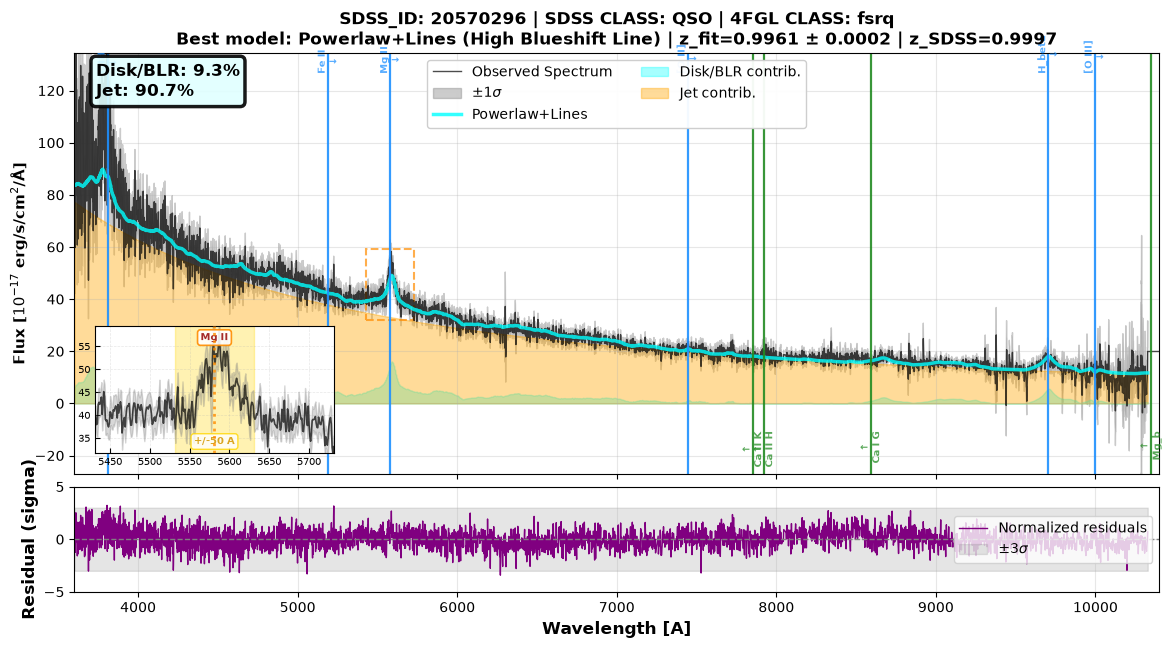


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [33]:
spec = bz_inspect(results, model='best')

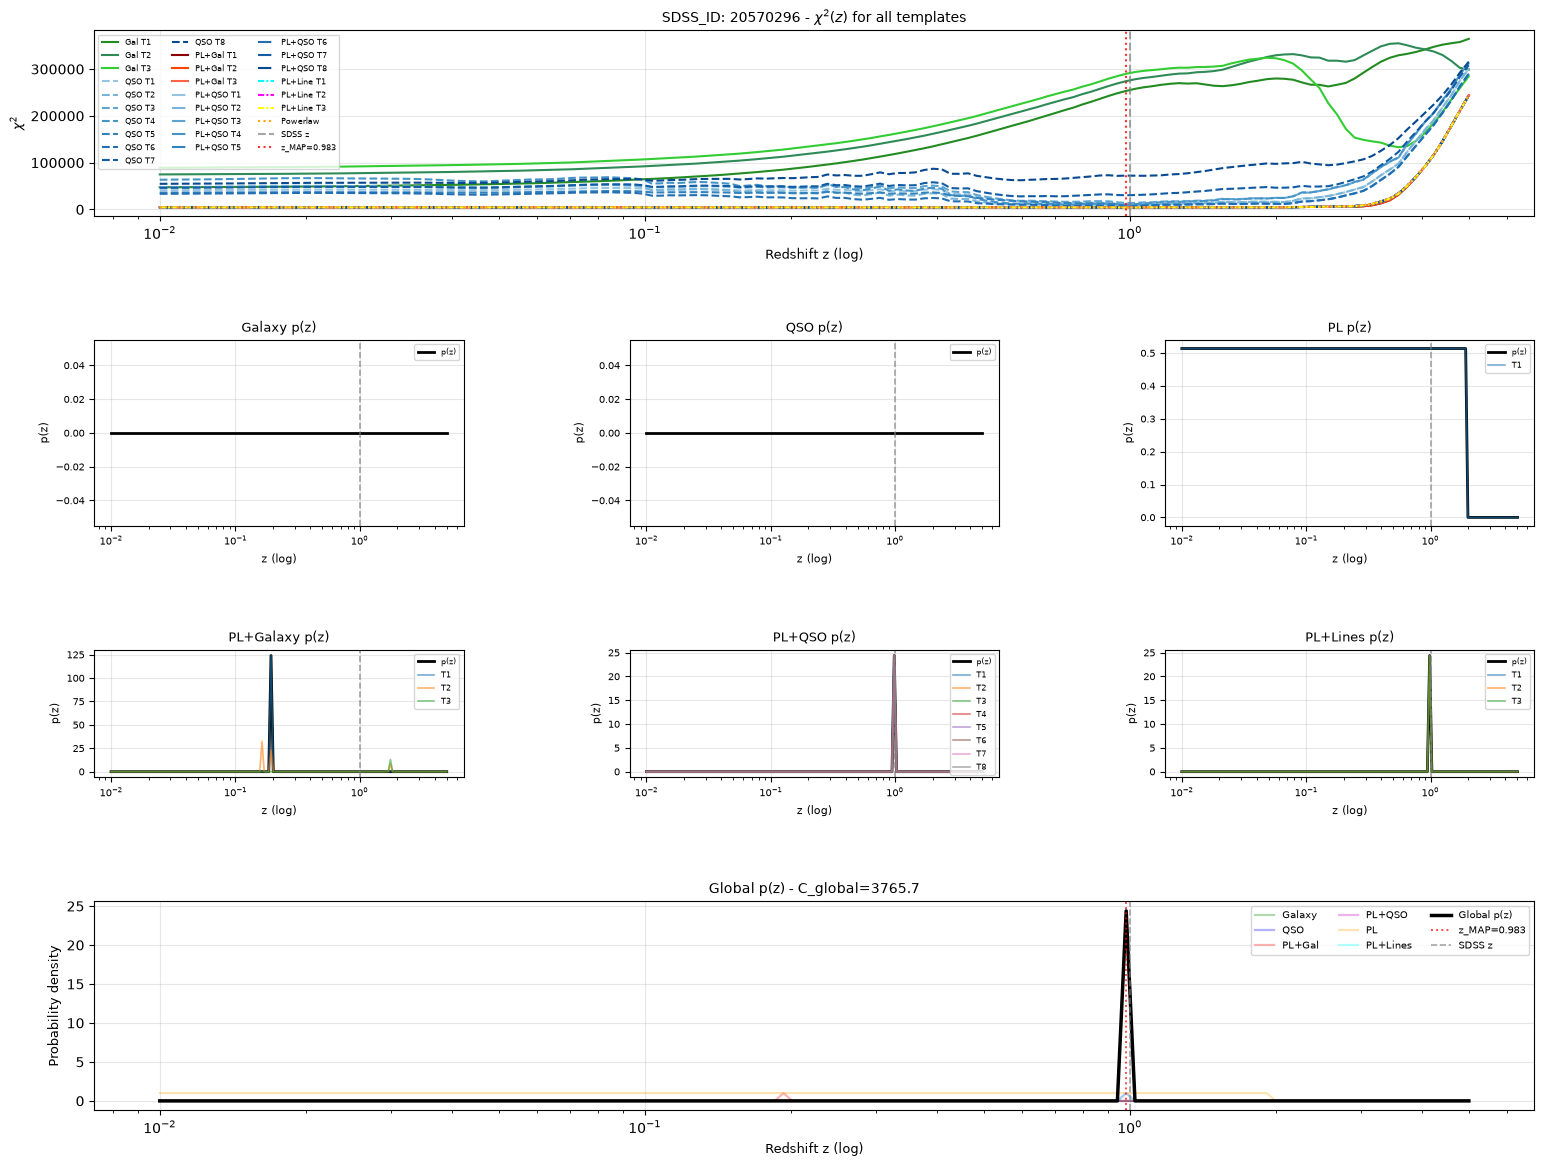

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


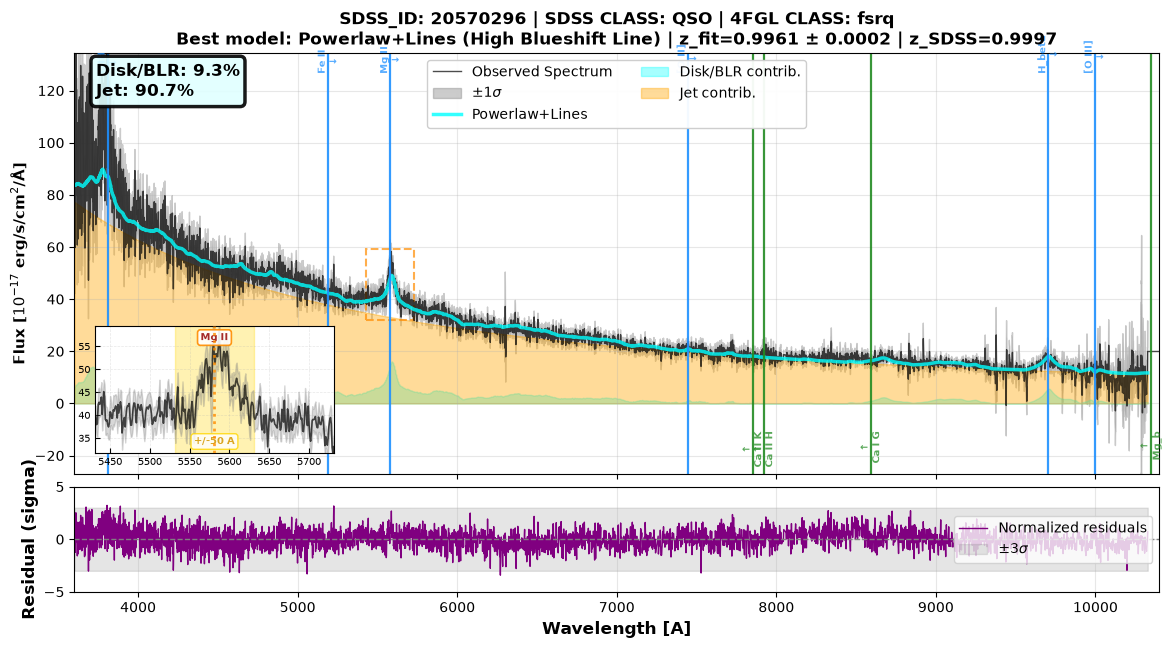


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [17]:
# Also show the chi2/p(z) diagnostic figure
spec = bz_inspect(results, model='best', posterior=True)

## 8. Customising the plot

All panels are individually controllable. Here are the most useful combinations.

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


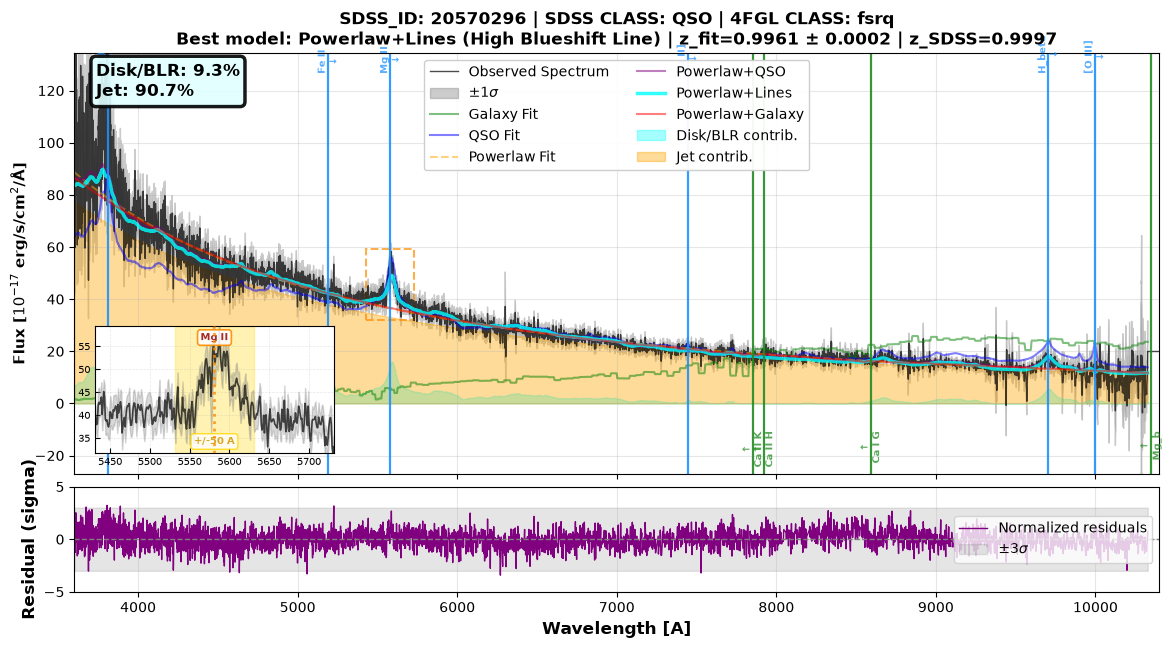


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [18]:
# All models overlaid — useful for comparing fits
spec = bz_inspect(results, model='all')

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


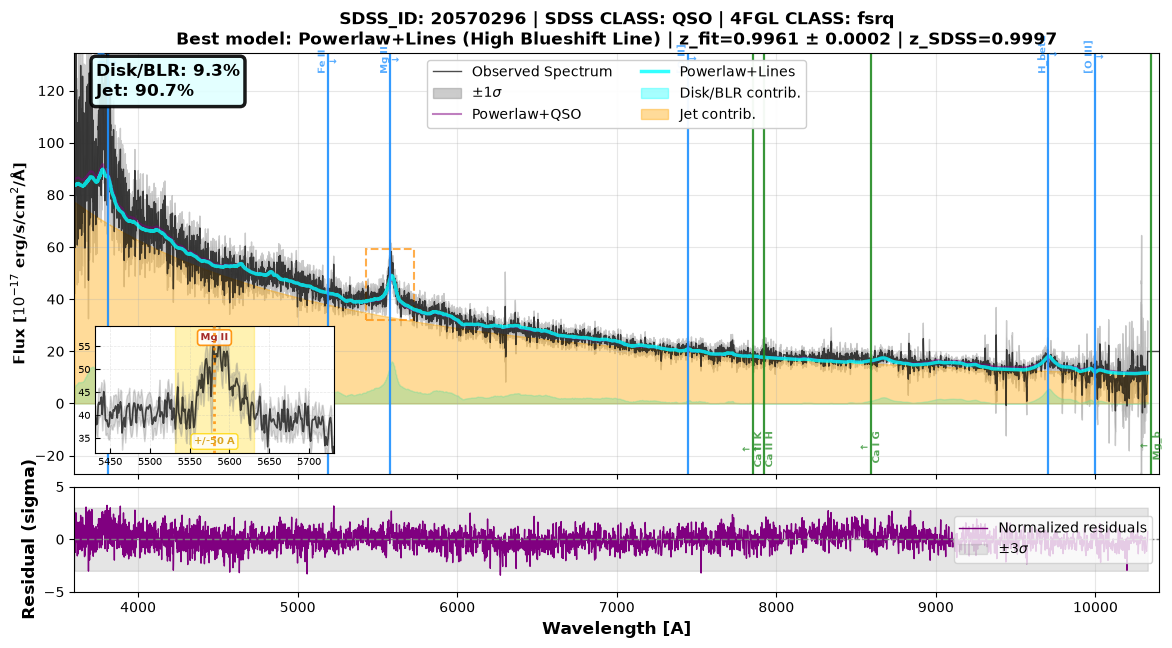


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [19]:
# Specific models only
spec = bz_inspect(results, model=['best', 'Powerlaw+QSO'])

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


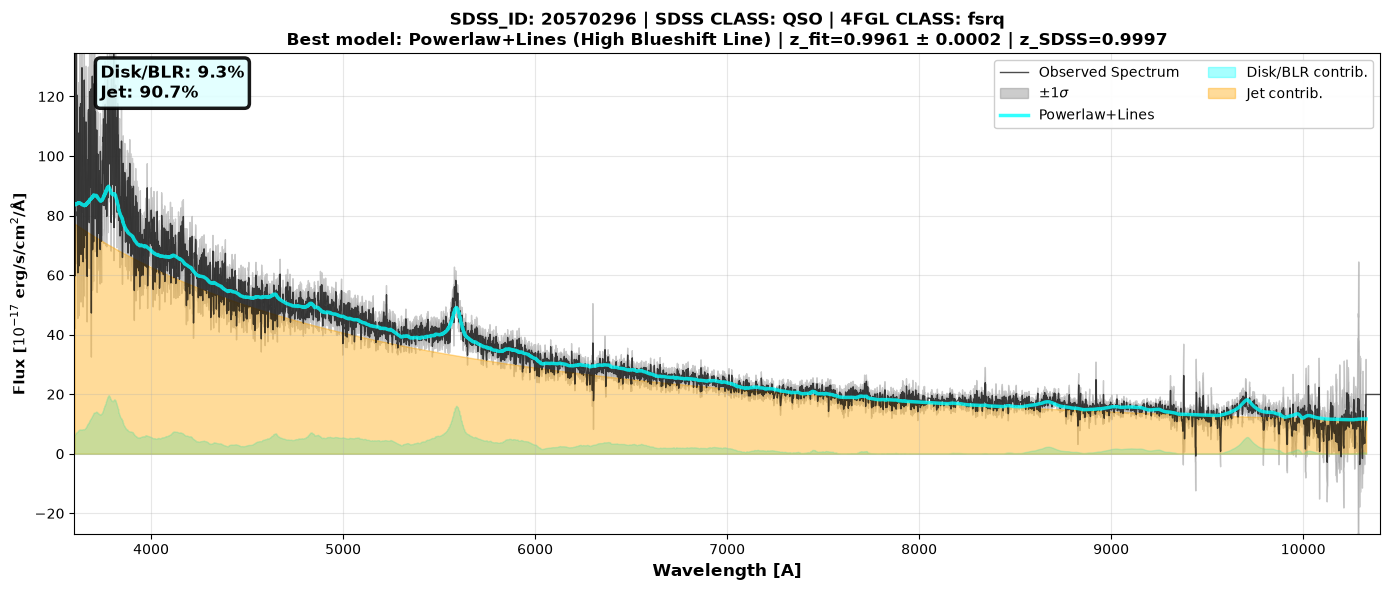


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [20]:
# Minimal clean plot
spec = bz_inspect(results, model='best',
                      show_inset=False,
                      show_line_markers=False,
                      show_residuals=False)

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


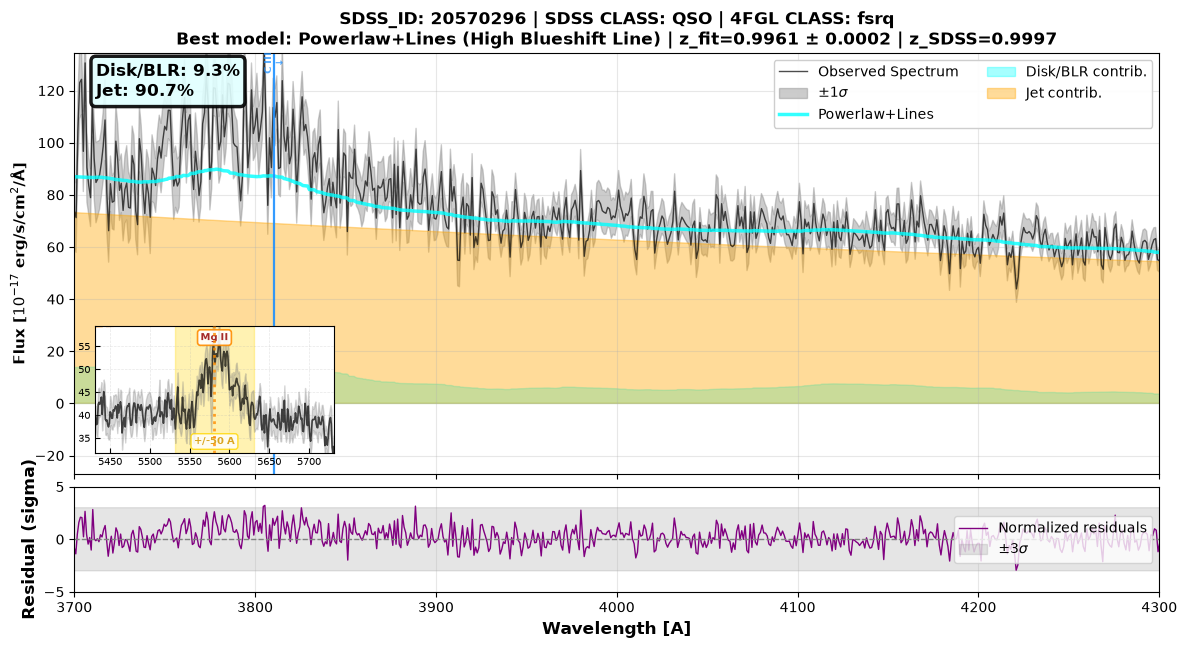


SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [21]:
# Zoom into specific wavelength range
spec = bz_inspect(results, model='best', wavelength_range=(3700, 4300))

  C III          : EW = -20.52 ±  1.34 Å, SNR = 15.3
  Mg II          : EW = -18.37 ±  0.90 Å, SNR = 20.5
  [O II]         : EW =  -2.40 ±  0.64 Å, SNR =  3.7
  H_beta         : EW = -25.53 ±  2.20 Å, SNR = 11.6
  [O III]        : EW =  -5.80 ±  1.56 Å, SNR =  3.7
  Ca II K        : EW =   2.94 ±  0.84 Å, SNR =  3.5
  Ca I G         : EW =   2.50 ±  0.41 Å, SNR =  6.0


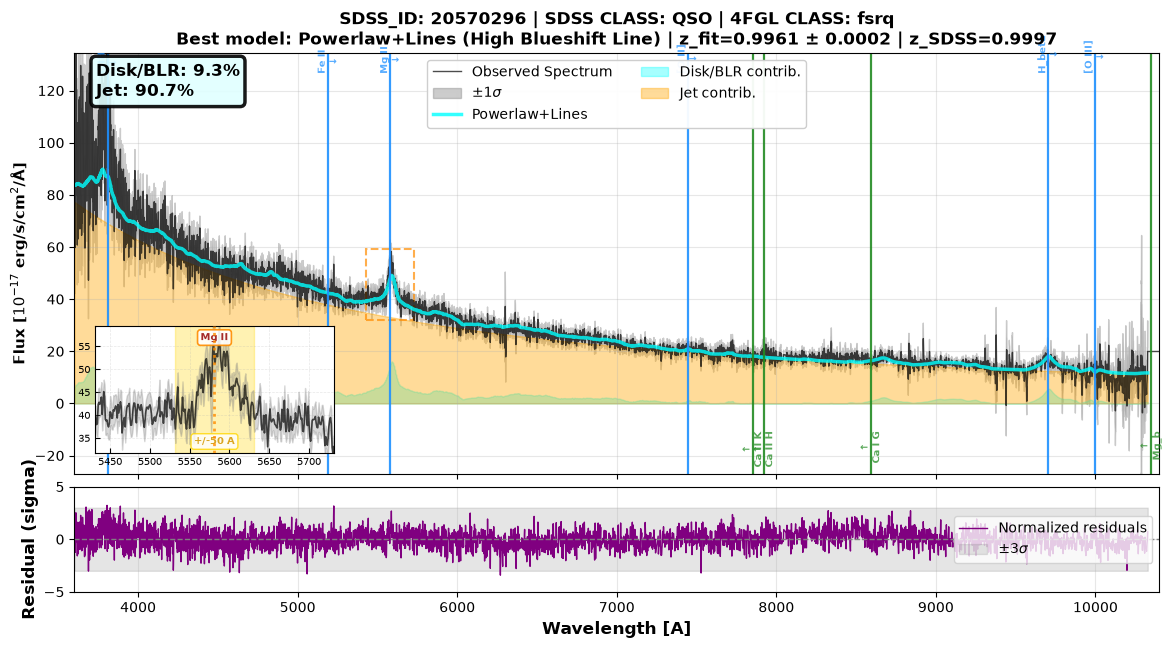

Saved: my_plots/20570296.pdf

SDSS_ID: 20570296
  z_MAP=0.9829, z_fit=0.9961 ± 0.0002, z_SDSS=0.9997
  Best model: Powerlaw+Lines (High Blueshift Line) (chi2=3312.51)


In [22]:
# Save to PDF - Creates a folder called 'my_plots' in the current working directory
spec = bz_inspect(results, model='best', save_dir = 'my_plots') 

## 9. Classification summary

`bz_classify` prints a one-line human-readable description of the source —
its blazar class, jet fraction, S/N, and key detected spectral lines.
Useful for quickly understanding a source without looking at the plots.

In [23]:
summary = bz_classify(results) 


SDSS_ID: 20570296 | Fermi: fsrq | SDSS: QSO
----------------------------------------------------------------------
FSRQ candidate at z=0.9961 | Jet-dominated (90.7%) | Emission lines only | S/N=10.5 | C III (emi, S/N=15.3) | Mg II (emi, S/N=20.5) | [O II] (emi, S/N=3.7)



## 10. Comparing Multiple Sources 

`bz_compare` look at multiple source at the same time and compare their properties, 
and can be used to compare properties. 

Loaded: obj_80861309_59265.pkl.gz
  [1] Powerlaw+Galaxy, z=0.184
Loaded: obj_56366226_59209.pkl.gz
  [2] Powerlaw+Galaxy, z=0.427
Loaded: obj_75253279_59940.pkl.gz
  [3] Powerlaw+QSO (High Blueshift z=0.2), z=0.267
Loaded: obj_61543192_59340.pkl.gz
  [4] Powerlaw+QSO (High Blueshift z=1.5), z=0.683
Loaded: obj_61915043_59256.pkl.gz
  [5] Powerlaw+Lines (High Blueshift Line), z=1.064
Loaded: obj_79816708_60050.pkl.gz
  [6] Powerlaw+Lines (High EW Line), z=0.893

Saved: paper_plots/multi_object_comparison.pdf


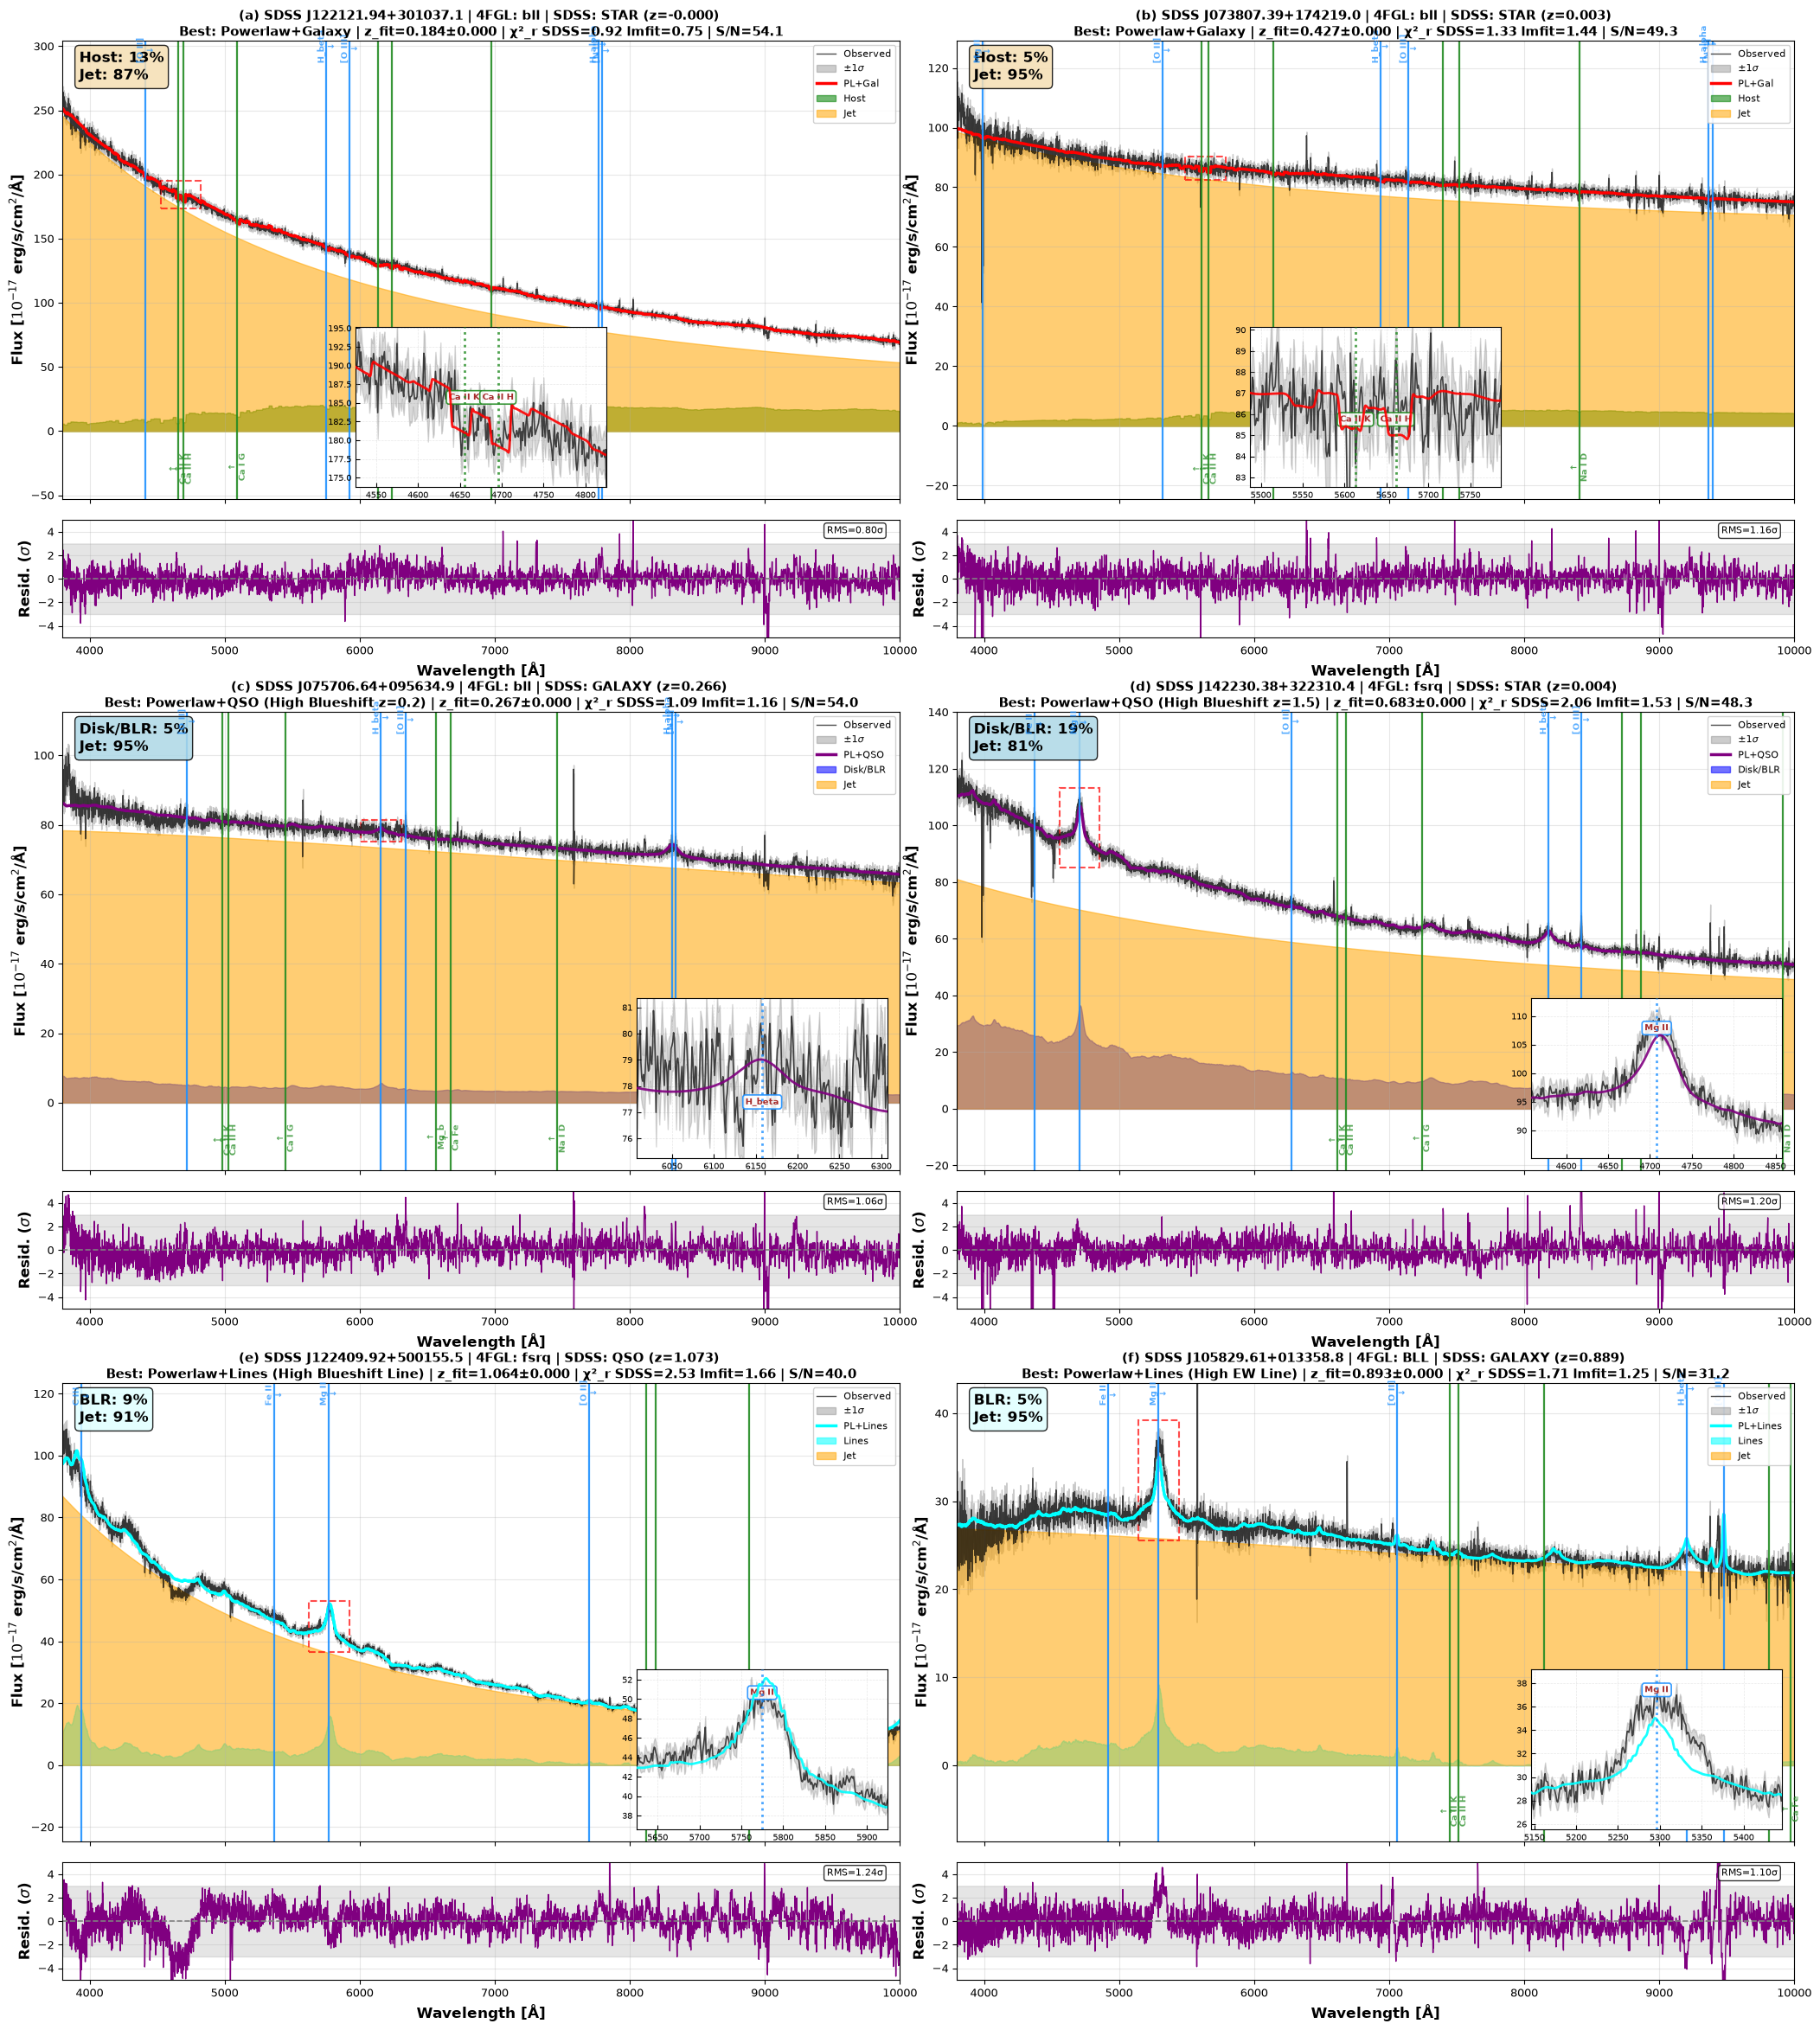

In [24]:
object_list = [
    # Recommended — use MJD from VAC directly
    {'SDSS_ID': str(row['SDSS_ID']), 'MJD': int(row['MJD'])}
    # Alternative — find MJD from cache filenames
    # {'SDSS_ID': str(row['SDSS_ID']), 'MJD': get_mjd(str(row['SDSS_ID']), cache)}
    for row in top6
]

fig = bz_compare(
    object_list = object_list,
    cache       = cache,
    final_bl    = vac,
    n_cols      = 2,
)


## 11. Equivalent width measurements

`measure_ew` measures equivalent widths for 16 emission and absorption
features using adaptive window selection. A line is detected if S/N >= 3.
Positive EW = absorption, negative EW = emission.

In [25]:
spec   = results['spectrum']
z_best = results['lmfit_results']['z_best']

results_ew = measure_ew(
    spec['common_wave'], spec['flux_resamp'],
    spec['err_resamp'],  spec['fit_mask'], z_best
)

print(f"Equivalent widths at z = {z_best:.4f}:")
print(f"\n{'Line':<15} {'Type':<12} {'EW (A)':>10} {'±err':>8} {'S/N':>8} {'Det':>5}")
print('-' * 60)
for name, obs, ew, ew_err, snr, detected, ltype, window in results_ew:
    if np.isfinite(ew):
        flag = '✓' if detected else ''
        print(f"{name:<15} {ltype:<12} {ew:>10.2f} {ew_err:>8.2f} {snr:>8.1f} {flag:>5}")

Equivalent widths at z = 0.9961:

Line            Type             EW (A)     ±err      S/N   Det
------------------------------------------------------------
C III           emission         -20.52     1.34     15.3     ✓
Fe II           emission           1.25     0.45      2.7      
Mg II           emission         -18.37     0.90     20.5     ✓
[O II]          emission          -2.40     0.64      3.7     ✓
H_beta          emission         -25.53     2.20     11.6     ✓
[O III]         emission          -5.80     1.56      3.7     ✓
Ca II K         absorption         2.94     0.84      3.5     ✓
Ca II H         absorption        -2.45     0.87      2.8      
Ca I G          absorption         2.50     0.41      6.0     ✓
Mg_b            absorption         3.32     2.08      1.6      


## 12. EW summary plot

`bz_lines` produces a visual summary of all detected spectral lines.
Blue = emission lines, green = absorption lines.
The red dashed line marks the |EW| = 5 Å BL Lac/FSRQ boundary.

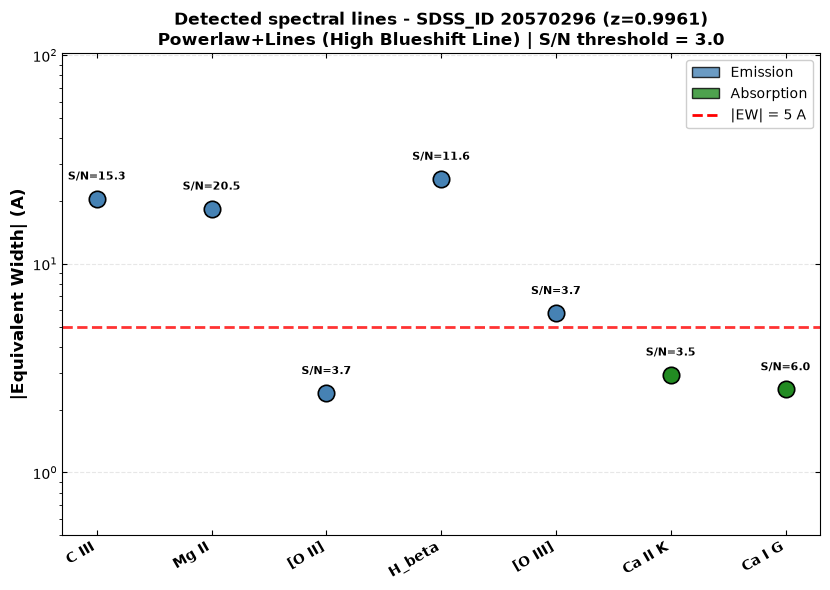

In [26]:
fig = bz_lines(results, min_snr=3.0)

## 13. Redshift posterior

The full p(z) posterior is stored in the cache. Here we plot the global
posterior alongside the best-fit family contribution, and identify
any secondary redshift solutions.

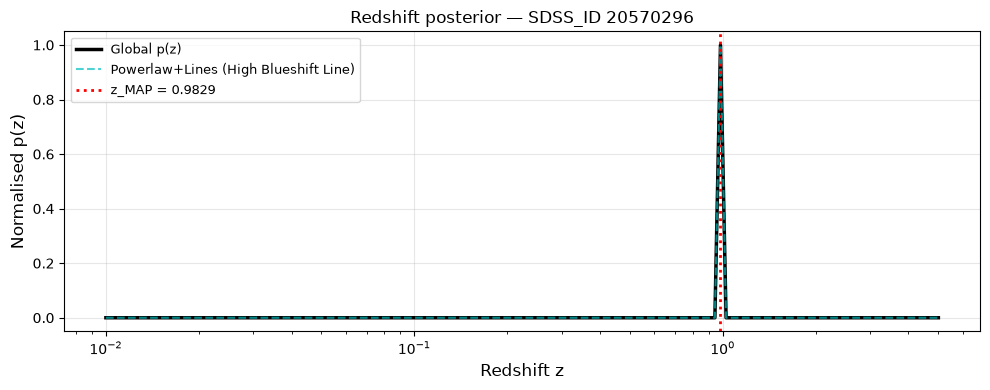


Top redshift solutions:
Rank          z  Rel. height   Note
----------------------------------------
1        0.9829        1.000   primary


In [27]:
pz     = results['pz_results']
z_grid = results['chi2_grids']['z_grid']

family_pz_map = {
    'Powerlaw+Galaxy' : ('pz_galpl',  'r--'),
    'Powerlaw+QSO'    : ('pz_qsopl',  'm--'),
    'Powerlaw+Lines'  : ('pz_linepl', 'c--'),
    'Galaxy'          : ('pz_gal',    'g--'),
    'QSO'             : ('pz_qso',    'b--'),
    'Powerlaw'        : ('pz_pl',     'orange'),
}

best_label = results['lmfit_results']['best_label']
pz_key, style = next(
    ((v[0], v[1]) for k, v in family_pz_map.items() if best_label.startswith(k)),
    ('pz_gal', 'g--')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z_grid, normalize_shape(pz['p_total']), 'k-',  lw=2.5, label='Global p(z)')
ax.plot(z_grid, normalize_shape(pz[pz_key]),    style, lw=1.5, alpha=0.7, label=best_label)
ax.axvline(pz['z_map_total'], color='red', ls=':', lw=2,
           label=f"z_MAP = {pz['z_map_total']:.4f}")
ax.set_xscale('log')
ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Normalised p(z)', fontsize=12)
ax.set_title(f"Redshift posterior — SDSS_ID {meta['SDSS_ID']}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Top redshift solutions
peaks = get_redshift_peaks(pz['p_total'], z_grid)
print(f"\nTop redshift solutions:")
print(f"{'Rank':<6} {'z':>8} {'Rel. height':>12}   Note")
print('-' * 40)
for i, (z_peak, height) in enumerate(peaks[:3]):
    note = 'primary' if i == 0 else f'alternative {i}'
    print(f"{i+1:<6} {z_peak:>8.4f} {height:>12.3f}   {note}")

## 14. Raw fit parameters

All best-fit parameters are stored in the cache and can be accessed
directly for custom analysis — useful if you want to build on the
results beyond what the VAC columns provide.

In [28]:
lmfit = results['lmfit_results']

print(f"{'Parameter':<20} {'Value':>12} {'Stderr':>12}")
print('-' * 46)
for name, param in lmfit['best_fit_params']['params'].items():
    val     = param['value']
    err     = param['stderr']
    err_str = f"{err:.4f}" if err is not None else 'N/A'
    print(f"{name:<20} {val:>12.4f} {err_str:>12}")

print(f"\nchi2:        {lmfit['best_fit_params']['chisqr']:.2f}")
print(f"redchi:      {lmfit['best_fit_params']['redchi']:.3f}")
print(f"AICc margin: {lmfit['aicc_margin']:.1f}")
print(f"PL alpha:    {lmfit['pl_alpha']:.4f}")
print(f"PL delta:    {lmfit['pl_delta']:.4f}")

Parameter                   Value       Stderr
----------------------------------------------
scale_line                83.5800       2.1015
A                         40.6766       0.1422
alpha                     -1.2969       0.0318
delta                     -1.2000       0.0793
lam0                    5000.0000       0.0000
z                          0.9961       0.0002

chi2:        3312.51
redchi:      0.728
AICc margin: 49.0
PL alpha:    -1.2969
PL delta:    -1.2000


## 15. Looping over multiple sources

You can load multiple sources and extract parameters in bulk — useful for
building custom population plots or cross-matching with other catalogues.
Here we load all three sources in the test cache.

In [29]:
summary = []

for fname in sorted(cache.list_cached_objects()):
    parts   = fname.replace('.pkl.gz', '').split('_')
    sdss_id = parts[1]
    mjd     = int(parts[2]) if len(parts) > 2 else None
    try:
        res  = cache.load(sdss_id, mjd=mjd)
        lm   = res['lmfit_results']
        m    = res['metadata']
        c    = res['components']

        jet_frac = np.nan
        if lm['best_label'] == 'Powerlaw+Galaxy' and c['galpl_contrib']:
            jet_frac = c['galpl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+QSO') and c['qsopl_contrib']:
            jet_frac = c['qsopl_contrib']['frac_pl']
        elif lm['best_label'].startswith('Powerlaw+Lines') and c['linepl_contrib']:
            jet_frac = c['linepl_contrib']['frac_pl']

        summary.append({'SDSS_ID': sdss_id, 'best_label': lm['best_label'],
                         'z_best': lm['z_best'], 'jet_frac': jet_frac,
                         'sn': m['sn_median']})
    except Exception as e:
        print(f'  Skipped {fname}: {e}')

print(f'\nLoaded {len(summary)} sources')
print(f"\n{'SDSS_ID':<15} {'Model':<20} {'z':>8} {'f_jet':>8} {'S/N':>6}")
print('-' * 60)
for s in summary:
    jf = f"{s['jet_frac']*100:.1f}%" if np.isfinite(s['jet_frac']) else 'N/A'
    print(f"{s['SDSS_ID']:<15} {s['best_label']:<20} {s['z_best']:>8.4f} {jf:>8} {s['sn']:>6.1f}")

Found 7 cached objects in blazar_cache/
Loaded: obj_20570296_60027.pkl.gz
Loaded: obj_56366226_59209.pkl.gz
Loaded: obj_61543192_59340.pkl.gz
Loaded: obj_61915043_59256.pkl.gz
Loaded: obj_75253279_59940.pkl.gz
Loaded: obj_79816708_60050.pkl.gz
Loaded: obj_80861309_59265.pkl.gz

Loaded 7 sources

SDSS_ID         Model                       z    f_jet    S/N
------------------------------------------------------------
20570296        Powerlaw+Lines (High Blueshift Line)   0.9961    90.7%   10.5
56366226        Powerlaw+Galaxy        0.4269    95.2%   49.3
61543192        Powerlaw+QSO (High Blueshift z=1.5)   0.6827    81.2%   48.3
61915043        Powerlaw+Lines (High Blueshift Line)   1.0640    91.4%   40.0
75253279        Powerlaw+QSO (High Blueshift z=0.2)   0.2667    94.6%   54.0
79816708        Powerlaw+Lines (High EW Line)   0.8928    94.9%   31.2
80861309        Powerlaw+Galaxy        0.1835    87.2%   54.1


## 16. Population plot from cache results

`bz_population` takes a list of cached results and produces a scatter plot
and distribution of any two parameters. This is most informative with the
full 707-source cache — here we demonstrate with the test sources.

Found 7 cached objects in blazar_cache/
Loaded: obj_20570296_60027.pkl.gz
Loaded: obj_56366226_59209.pkl.gz
Loaded: obj_61543192_59340.pkl.gz
Loaded: obj_61915043_59256.pkl.gz
Loaded: obj_75253279_59940.pkl.gz
Loaded: obj_79816708_60050.pkl.gz
Loaded: obj_80861309_59265.pkl.gz


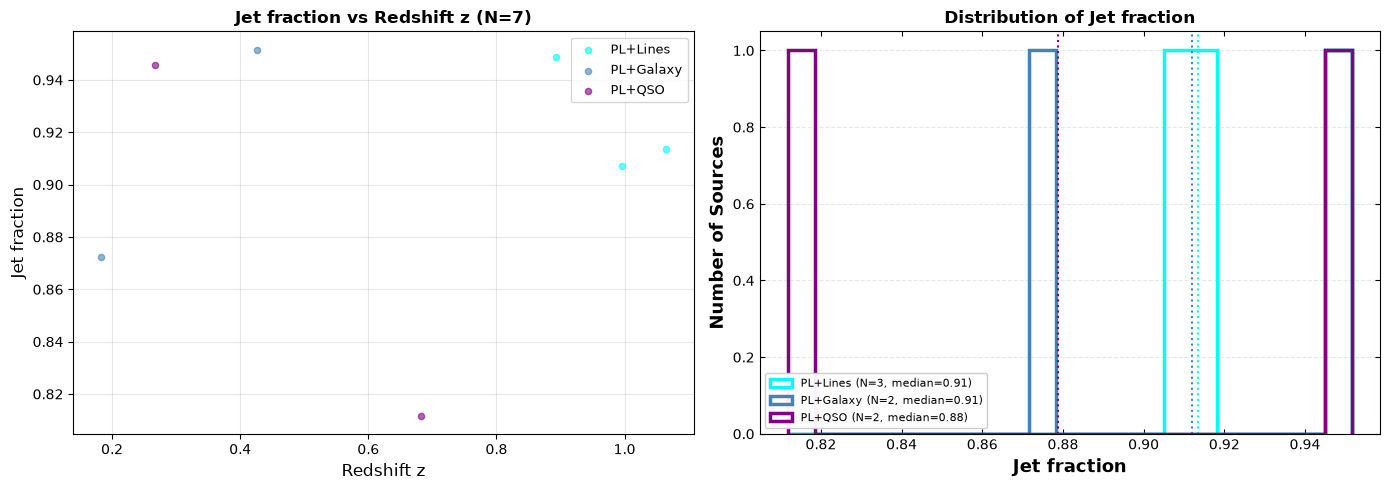

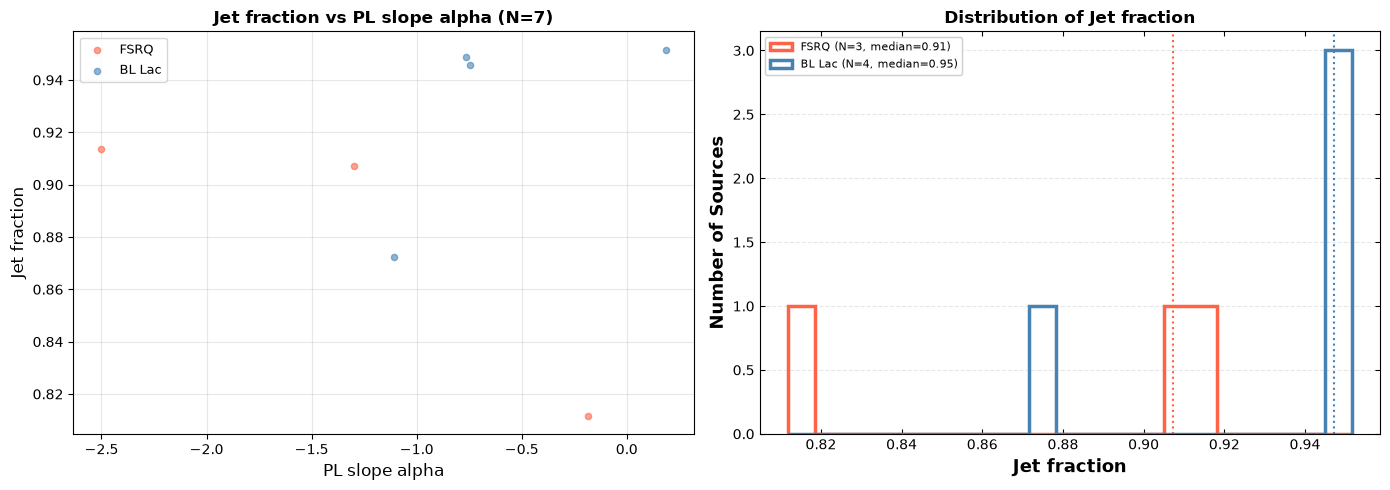

In [30]:
# Load all cached sources into a list
results_list = []
for fname in sorted(cache.list_cached_objects()):
    parts = fname.replace('.pkl.gz', '').split('_')
    try:
        results_list.append(cache.load(parts[1], mjd=int(parts[2])))
    except Exception:
        pass

# Jet fraction vs redshift
fig = bz_population(results_list, x_param='z_best', y_param='jet_frac',
                    color_by='best_label')

# PL alpha vs jet fraction coloured by Fermi class
fig = bz_population(results_list, x_param='pl_alpha', y_param='jet_frac',
                    color_by='fermi_class')

---

## About this notebook

**Authors:** Mohammed Iddrisu Nlowie (University of Edinburgh),
with supervision from Prof. James Aird (University of Edinburgh)
and Dr. Eli Kasai (University of Namibia).

**Last updated:** 2026 June

---

### Citing this work

If you use the Fermi/SDSS-V Blazar VAC 0034 or blazarkit in published research,
please cite:

**Paper:**
> Nlowie et al. (Submitted) — *Optical Spectroscopic Analysis of Fermi Detected
> Blazars using SDSS-V*. MNRAS.

**Package:**
> Nlowie et al. (2026) — *blazarkit: Plotting and analysis utilities for
> Fermi/SDSS-V blazar spectral fitting*. Zenodo. doi:..../zenodo.XXXXXXX

**Data:**
> Nlowie et al. (2026) — *Fermi/SDSS-V Blazar Spectral Fitting Results:
> Main Sample*. Zenodo. doi:.../zenodo.YYYYYYY 

Please also [cite SDSS](https://www.sdss.org/collaboration/citing-sdss/) and 
[SDSS-V Collaboration et al.] when using the SDSS-V or DR20 data.

If you use `astropy` in your research, please follow the
[astropy citation guidelines](https://www.astropy.org/acknowledging.html).
